In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TASK-01
df=pd.read_csv(r"E:\DECODE LABS Intern\WEEK 1\student_dataset_10000_rows.csv")
df.head()
df.shape
df.columns
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  str    
dtypes: float64(1), int64(6), str(1)
memory usage: 625.1 KB


In [2]:
# Check Missing values
df.isnull().sum()
# Check duplicates
df.duplicated().sum()
# Check placement_status column uniqueness
df['placement_status'].value_counts()
# check all columns names(valid or not)
df.columns
# Handle column names if space in names
df.columns=df.columns.str.strip()
# Check Overall summary
df.describe()
# Saving Cleaned dataset
df.to_csv(r"E:\DECODE LABS Intern\WEEK 1\students_cleaned_dataset.csv")

In [3]:
# Statistical Data Analysis
df.describe()

# % of placement status values
(df['placement_status'].value_counts(normalize=True)*100).round(2)

# Coreleation
df.corr(numeric_only=True)['exam_score'].sort_values(ascending=False)

# Average Exam Score by Placement
df.groupby('placement_status')['exam_score'].mean()

# Average Exam Score by Study_hours
df.groupby('study_hours')['exam_score'].mean()

study_hours
1     71.264562
2     75.169142
3     78.974939
4     81.845483
5     84.964142
6     88.620043
7     90.539568
8     93.297697
9     95.462126
10    96.574628
11    97.303283
Name: exam_score, dtype: float64

### Coreleation
- 0.56 (exam_score vs study hours)  
- 0.38(exam_score vs assignments)  
- 0.31(exam_score vs previous score)  
- 0.14(exam score vs sleep hours)  
- -0.15(exam score vs internet usage)  

- study_hours is the biggest factor in exam score (0.56)  
- assignments_completed is 2nd most important (0.39)  
- attendance has a small positive effect (0.22)  
- internet_usage slightly hurts exam score (-0.15)  
- sleep_hours has almost no effect (0.14)  

### Questions/Answers
* What is the average study time?  
The average study time is 6 hours.     
* Do students who study more get higher scores?    
Yes! Average of 6 hours study will target 90+ exam scores.    
* What is the average attendance?  
Average attendence is 70.    
* Does attendance impact exam scores?    
yes Of course Low attendence move to low marks and high attendence target high marks.    
* How much do students sleep on average?    
The average sleep hours is 6.5 hours.  
* Does more sleep improve performance?    
yes!more sleep hours give better performance like if a student sleep 8 to 9 hours a day it give better 100% result.  
* Is higher internet usage helping or hurting performance?    
According to dataset High internet usage helping performance.  
* Do students with higher previous scores also perform well in exams?    
yes!  
* How many students are Placed?    
8356 students are placed(83.56%)  
* How many are Not Placed?    
1644 students are unplaced.(16.44%)  

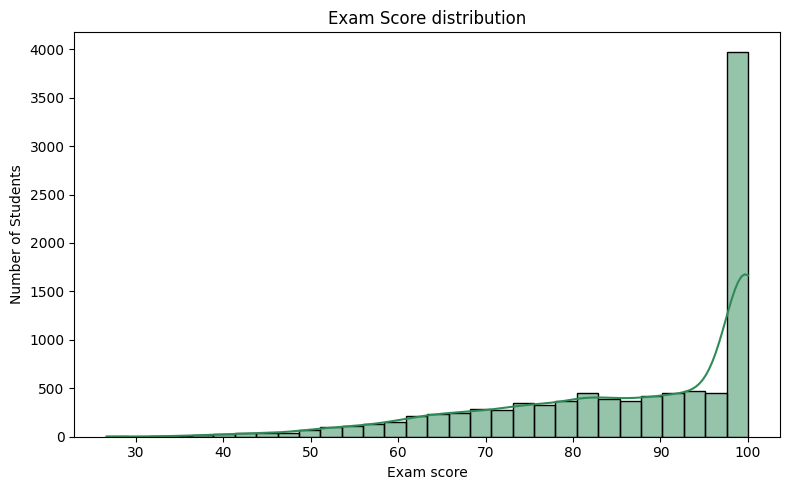

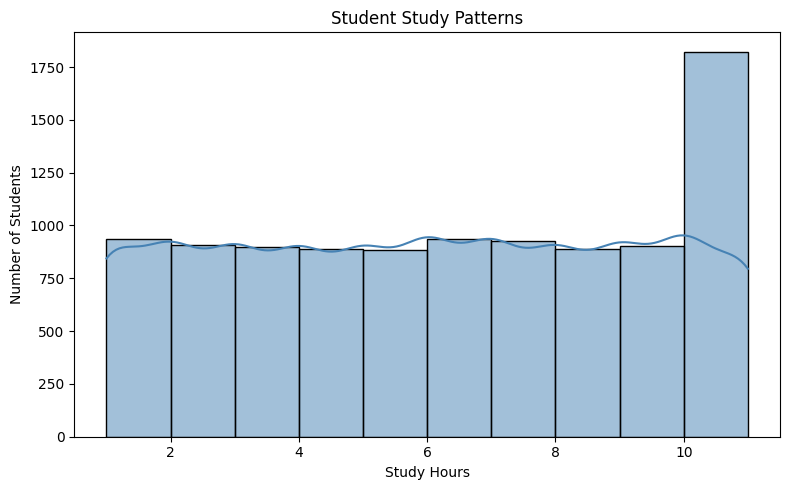

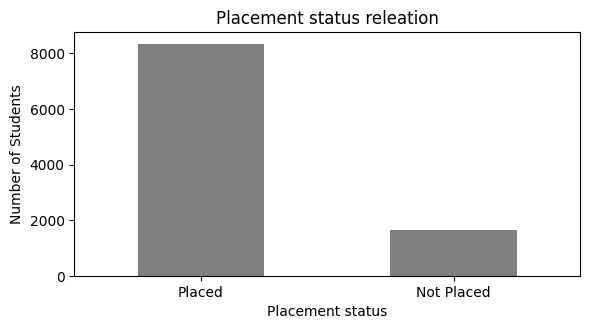

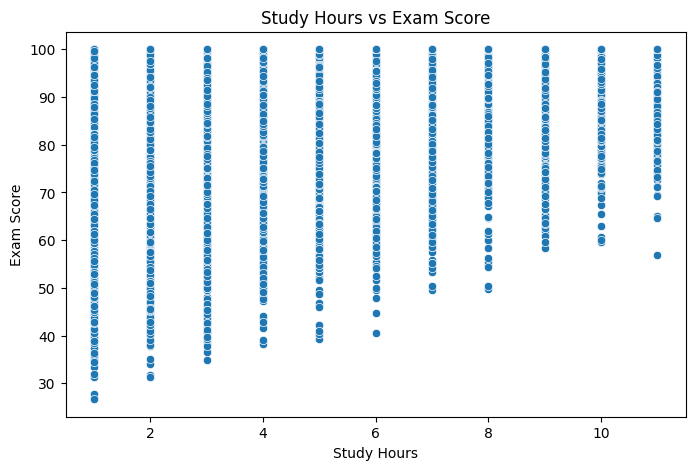

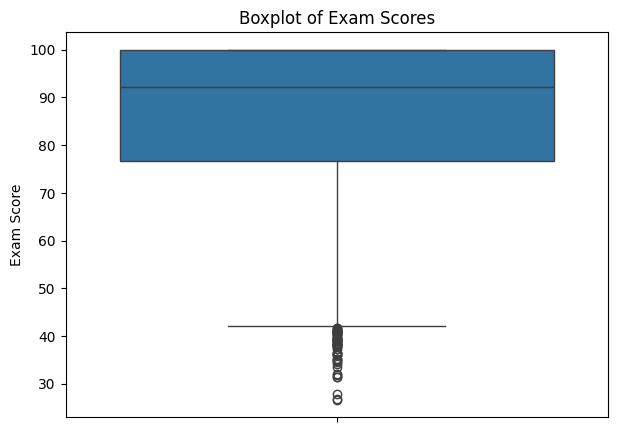

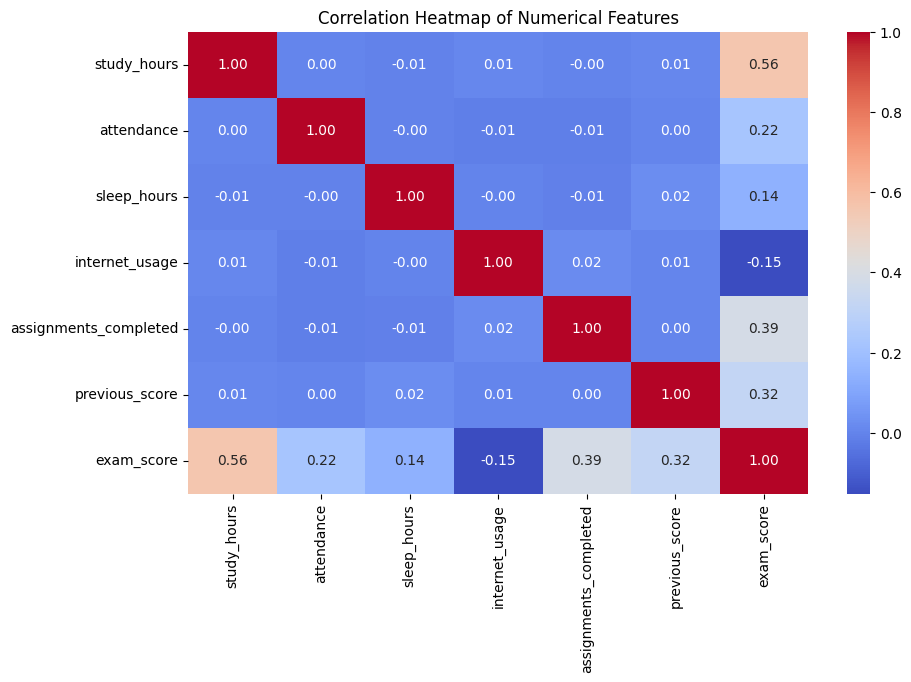

In [4]:
# Data Visualization
#Chart-01 Exam Score Distribution(Histogram)
plt.figure(figsize=(8,5))
sns.histplot(df['exam_score'], bins=30, kde=True,color='seagreen',edgecolor='black')
plt.title('Exam Score distribution')
plt.xlabel('Exam score')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig(r'E:\DECODE LABS Intern\WEEK 1\Charts\Exam Score distribution.png',dpi=300,bbox_inches='tight')
plt.show()

#Student Study Patterns
plt.figure(figsize=(8,5))
sns.histplot(df['study_hours'], bins=10, kde=True,color='steelblue',edgecolor='black')
plt.title('Student Study Patterns')
plt.xlabel('Study Hours')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig(r'E:\DECODE LABS Intern\WEEK 1\Charts\Student Study Patterns.png',dpi=300,bbox_inches='tight')
plt.show()

#Placement status releation
plt.figure(figsize=(6,4))
df['placement_status'].value_counts().plot(kind='bar',color='grey')
plt.title('Placement status releation')
plt.xlabel('Placement status')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.xticks(rotation=-00)
plt.savefig(r'E:\DECODE LABS Intern\WEEK 1\Charts\Placement status releation.png',dpi=300,bbox_inches='tight')
plt.show()

#Study Hours vs Exam Score
plt.figure(figsize=(8,5))
sns.scatterplot(x='study_hours', y='exam_score', data=df)
plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.savefig(r'E:\DECODE LABS Intern\WEEK 1\Charts\Study Hours vs Exam Score.png',dpi=300,bbox_inches='tight')
plt.show()

#Box plot
plt.figure(figsize=(7,5))
sns.boxplot(y=df['exam_score'])
plt.title("Boxplot of Exam Scores")
plt.ylabel("Exam Score")
plt.savefig(r'E:\DECODE LABS Intern\WEEK 1\Charts\Boxplot of Exam Scores.png',dpi=300,bbox_inches='tight')
plt.show()
#Most students score between 79-100 with a median of 91,
#but a small group of outlier students are scoring as low as 28.

#Coreleation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.savefig(r'E:\DECODE LABS Intern\WEEK 1\Charts\Correlation Heatmap of Numerical Features.png',dpi=300,bbox_inches='tight')
plt.show()
#Study hours impact exam score the most (0.56), 
# followed by assignments and previous score.
# Internet usage slightly hurts performance.
# All other features are nearly independent of each other 

In [11]:
# Importing Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

#Load the datset
df = pd.read_csv(r"E:\DECODE LABS Intern\WEEK 1\students_cleaned_dataset.csv")

# Defining Features (X)
X = df[['study_hours',
        'attendance',
        'sleep_hours',
        'internet_usage',
        'assignments_completed',
        'previous_score']]

#Now defining Target (y)
y = df['exam_score']

#Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Now create model
model = LinearRegression()

#Train the model
model.fit(X_train, y_train)

#Make predictions
y_pred = model.predict(X_test)

#Evaluate Model
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

MAE: 6.917285717910663
RMSE: 8.793159369855418
R2 Score: 0.6634458623051923


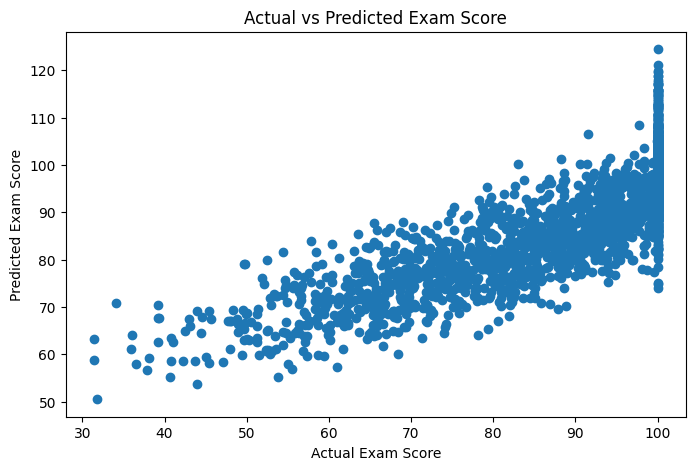

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Score")
plt.show()